# Machine Learning for Water Safety Prediction in South Africa

**Group Members**

22420947 - Gumede SN

22410169 - Maduna OAU

22315668 - Hlongwane MQ

22432331 - Ntuli AL

# 1. Problem Statement

Access to safe drinking water is an important public health concern in South Africa, particularly for communities that rely on rivers and other natural water sources. Traditional laboratory testing can be time-consuming and costly, making it difficult to obtain an immediate indication of whether a water sample may be suitable for drinking.

This machine learning project aims to develop a binary classification model that predicts whether a water sample collected from a South African river is safe (potable) or unsafe (non-potable) for drinking. The model will use measurable physicochemical water-quality parameters, including pH, dissolved oxygen, electrical conductivity, and air temperature, as input features.

The intended users are community water monitors, citizen scientists, and local water safety initiatives, who can use the model as a quick and low-cost preliminary screening tool before more comprehensive laboratory testing is performed.

The model will be considered successful if it can classify water samples with reasonable predictive accuracy, while placing particular emphasis on high recall for the unsafe class. This is because failing to identify an unsafe water sample (false negative) could have more serious consequences than incorrectly flagging a safe sample as unsafe (false positive). The system is therefore intended to serve as an early-warning and screening tool, rather than a replacement for certified laboratory water-quality testing.

# 2. Data Collection


**Source**: [Be-Resilient Citizen Science Water Quality Data (South Africa)](https://ihp-wins.unesco.org/dataset/showcase-be-resilient-citizen-science-water-quality-data-south-africa) — UNESCO Intergovernmental Hydrological Programme (IHP), collected by trained citizen scientists/volunteers across South African Biosphere Reserves.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('/content/drive/MyDrive/TP2 PROJECT SEPTEMBER 2026/citizen-science-water-quality-monitoring-wq-parameters_local_time.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (480, 23)


,Biosphere,id,river,site,weather,other_weather,start_comment,dissolved_oxgen_ppm,dissolved_oxygen_percent,time,Nitrate,Phosphate,Solinity (Parts per Thousand),Salinity Percentage,tds,Electrical Conductivity,PH,Irrigation Suitability,Air Temperature,latitude,longitude,Altitude (m),Location Accuracy (m)
0,Kruger 2 Canyons BR,Kubjaname Site 1,Kubjaname,Site 1,partly_cloudy,NaN,NaN,NaN,NaN,03/13/2024 08:31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pH reading indicates the water is NOT suitable...,NaN,-24.304498,30.504863,609.0,5.000
1,Kruger 2 Canyons BR,Kubjaname Site 3,Kubjaname,Site 3,partly_cloudy,NaN,NaN,NaN,224.7,03/13/2024 09:10,NaN,NaN,NaN,NaN,NaN,73.3,8.11,pH reading indicates the water is suitable for...,26.8,-24.302362,30.505223,622.8,4.800
2,Kruger 2 Canyons BR,Olifants Site 1,Olifants,Site 1,light_rain,NaN,NaN,NaN,146.7,03/14/2024 08:08,NaN,NaN,NaN,NaN,NaN,199.0,8.59,pH reading indicates the water is NOT suitable...,26.3,-24.361747,30.658613,467.4,4.100
3,Kruger 2 Canyons BR,Moetladimo Site 1,Moetladimo,Site 1,cloudy,NaN,NaN,NaN,125.7,03/19/2024 07:52,NaN,NaN,NaN,NaN,NaN,47.5,8.19,pH reading indicates the water is suitable for...,25.3,-24.258722,30.453870,610.2,3.814
4,Vhembe BR,Levubu River Lambani site 1,Levubu River,Lambani site 1,sunny,NaN,NaN,3.34,43.2,06/21/2024 10:51,NaN,NaN,NaN,NaN,NaN,128.6,7.91,pH reading indicates the water is suitable for...,18.0,-22.745560,30.884358,391.7,5.000


**Note on labels**: This dataset does not include a pre-existing "safe/unsafe" label. Labels are derived by applying recognized water quality thresholds (informed by WHO / SANS 241 guidelines) to the raw sensor readings — I explained this in Section 5.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Biosphere                      480 non-null    object 
 1   id                             480 non-null    object 
 2   river                          480 non-null    object 
 3   site                           480 non-null    object 
 4   weather                        480 non-null    object 
 5   other_weather                  3 non-null      object 
 6   start_comment                  32 non-null     object 
 7   dissolved_oxgen_ppm            295 non-null    float64
 8   dissolved_oxygen_percent       312 non-null    float64
 9   time                           480 non-null    object 
 10  Nitrate                        0 non-null      float64
 11  Phosphate                      0 non-null      float64
 12  Solinity (Parts per Thousand)  0 non-null      flo

# 3. Data preparation

This dataset is kinda messy. There's three main issues to address:

1. **Fully/mostly empty columns** — 'Nitrate', 'Phosphate', 'TDS', 'Salinity', 'Solinity' are 100% empty; 'other_weather' and 'start_comment' are ~93-99% empty. We dropped these.
2. **Physically impossible outliers** — e.g. pH values above 14 (pH is only ever 0-14), dissolved oxygen readings far above realistic freshwater levels, and air temperatures over 200°C. These are almost certainly data entry errors and are treated as missing.
3. **Missing values** in the remaining usable columns ('PH', dissolved oxygen, 'Electrical Conductivity', 'Air Temperature') — imputed using the median value, grouped by Biosphere Reserve where possible (since baseline water chemistry naturally differs by region).

In [3]:
# Drop unusable columns
drop_cols = ['other_weather', 'start_comment', 'Nitrate', 'Phosphate',
             'Solinity (Parts per Thousand)', 'Salinity Percentage', 'tds', 'id']
df = df.drop(columns=drop_cols)

# Rename for convenience
df = df.rename(columns={
    'dissolved_oxgen_ppm': 'DO_ppm',
    'dissolved_oxygen_percent': 'DO_percent',
    'Electrical Conductivity': 'EC',
    'Air Temperature': 'AirTemp',
    'Altitude (m)': 'Altitude',
    'Location Accuracy (m)': 'LocAccuracy'
})

print("Shape after dropping unusable columns:", df.shape)
df.columns.tolist()

Shape after dropping unusable columns: (480, 15)


['Biosphere',
 'river',
 'site',
 'weather',
 'DO_ppm',
 'DO_percent',
 'time',
 'EC',
 'PH',
 'Irrigation Suitability',
 'AirTemp',
 'latitude',
 'longitude',
 'Altitude',
 'LocAccuracy']

Remove physically impossible values (treat as missing)

In [4]:
outlier_rules = {
    'PH':        (0, 14),
    'DO_ppm':    (0, 20),
    'DO_percent':(0, 150),
    'AirTemp':   (-5, 45),
}

for col, (lo, hi) in outlier_rules.items():
    n_before = df[col].notna().sum()
    df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan
    n_after = df[col].notna().sum()
    print(f"{col}: removed {n_before - n_after} impossible values")

PH: removed 3 impossible values
DO_ppm: removed 34 impossible values
DO_percent: removed 23 impossible values
AirTemp: removed 5 impossible values


checking for missing values in the main numerical features and replaces them with the median value for their Biosphere Reserve, using the overall median as a fallback

In [5]:
print("Missing values before imputation:")
print(df[['PH','DO_ppm','DO_percent','EC','AirTemp']].isnull().sum())

# Impute with median, grouped by Biosphere Reserve (falls back to global median)
num_cols = ['PH', 'DO_ppm', 'DO_percent', 'EC', 'AirTemp']
for col in num_cols:
    df[col] = df.groupby('Biosphere')[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after imputation:")
print(df[num_cols].isnull().sum())

Missing values before imputation:
PH             36
DO_ppm        219
DO_percent    191
EC              8
AirTemp        14
dtype: int64

Missing values after imputation:
PH            0
DO_ppm        0
DO_percent    0
EC            0
AirTemp       0
dtype: int64


# 4. Exploratory Data Analysis (EDA)


We're now looking at distributions, correlations, and regional patterns before engineering the target label.

Histogram graphs to show the distributions of the numerical water-quality features, adds a density curve to each.

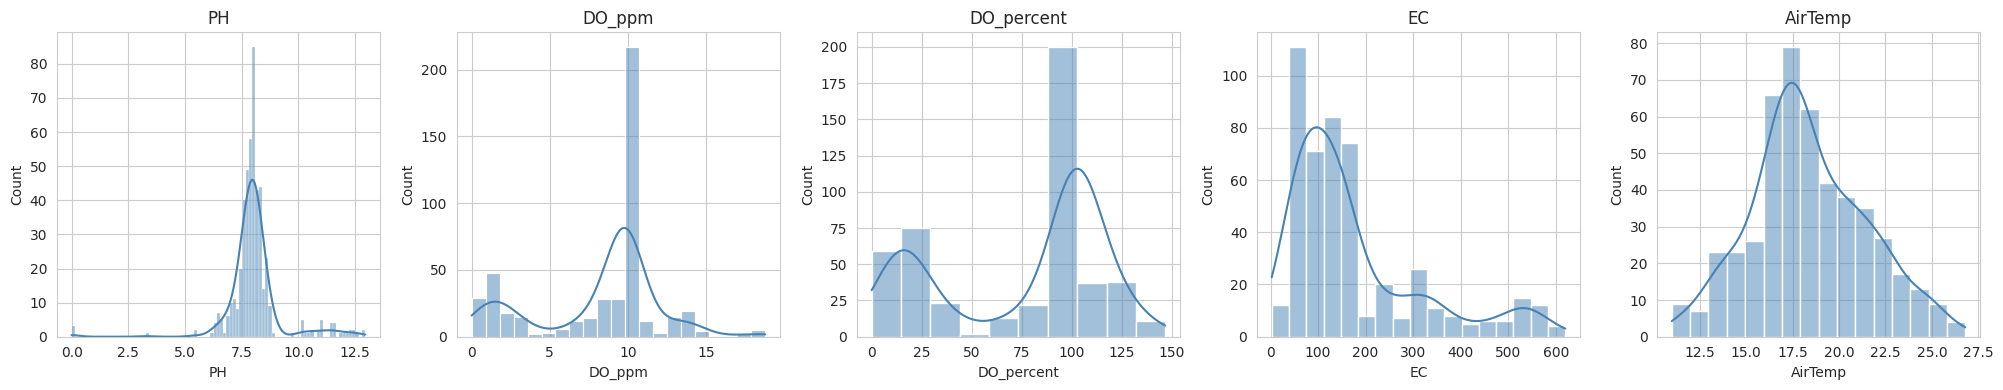

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=100)
plt.show()

This heatmap graph calculates the correlations between the numerical water-quality parameters and displays them, where the values show the strength and direction of each relationship

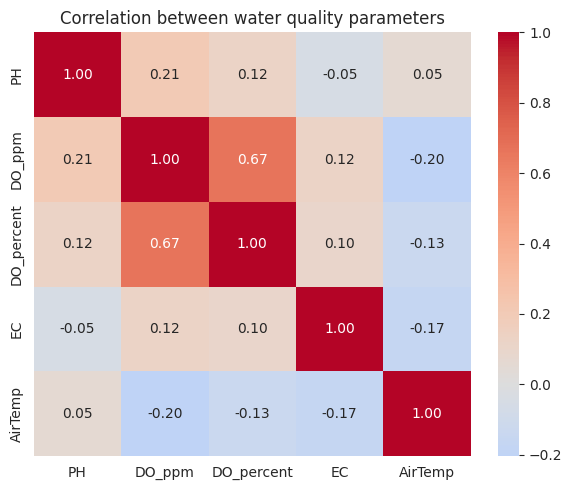

In [8]:
plt.figure(figsize=(6,5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation between water quality parameters')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=100)
plt.show()

Here we compared the distribution of pH values across different Biosphere Reserves using boxplots, saves the graph, and then counts how many samples come from each reserve.

/tmp/ipykernel_2496/1817211511.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Biosphere', y='PH', palette='Set2')


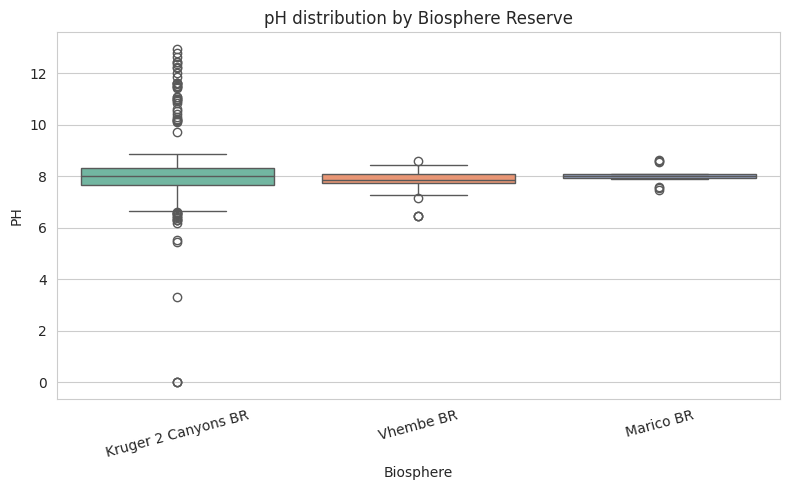

Biosphere
Kruger 2 Canyons BR    350
Vhembe BR              116
Marico BR               14
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Biosphere', y='PH', palette='Set2')
plt.title('pH distribution by Biosphere Reserve')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('eda_ph_by_biosphere.png', dpi=100)
plt.show()

print(df['Biosphere'].value_counts())

We compared the distribution of Electrical Conductivity (EC) across different Biosphere Reserves using boxplots

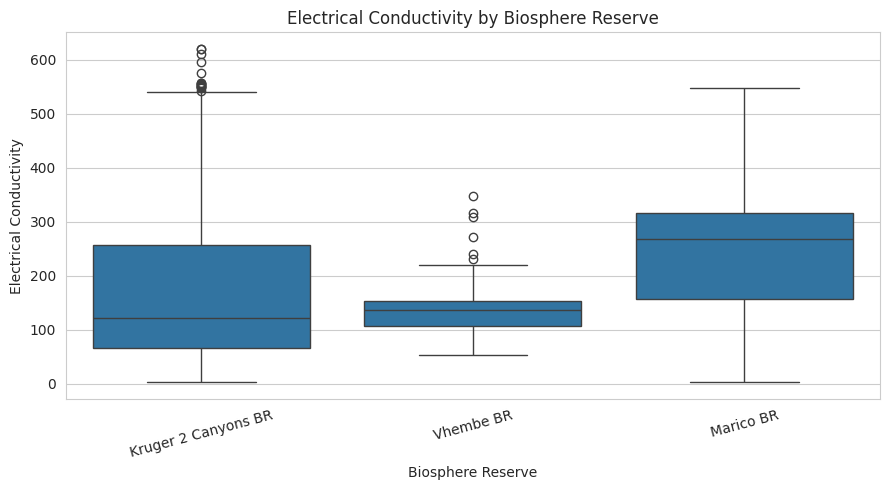

In [10]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Biosphere',
    y='EC'
)

plt.title('Electrical Conductivity by Biosphere Reserve')
plt.xlabel('Biosphere Reserve')
plt.ylabel('Electrical Conductivity')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('eda_ec_by_biosphere.png', dpi=100)
plt.show()

Scatter plot to examine the relationship between Electrical Conductivity (EC) and Dissolved Oxygen (DO), while using different colors to distinguish the Biosphere Reserves.

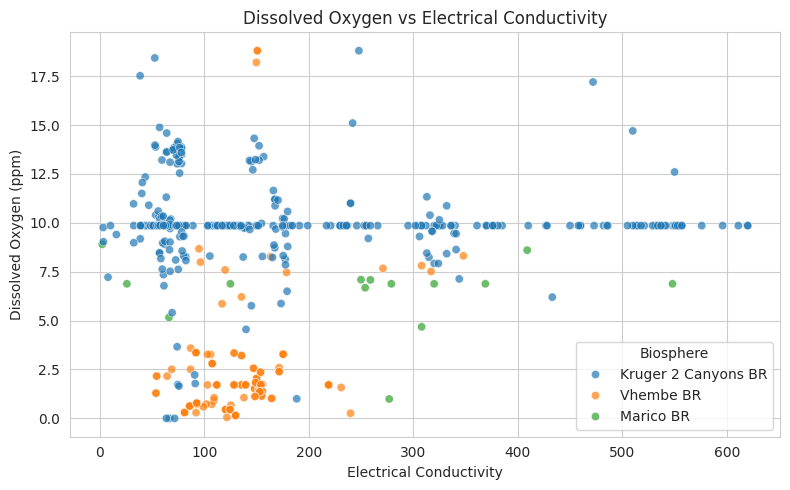

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='EC',
    y='DO_ppm',
    hue='Biosphere',
    alpha=0.7
)

plt.title('Dissolved Oxygen vs Electrical Conductivity')
plt.xlabel('Electrical Conductivity')
plt.ylabel('Dissolved Oxygen (ppm)')

plt.tight_layout()
plt.savefig('eda_do_vs_ec.png', dpi=100)
plt.show()

Scatter plot to examine the relationship between pH and Electrical Conductivity (EC), using different colors to distinguish the Biosphere Reserves.

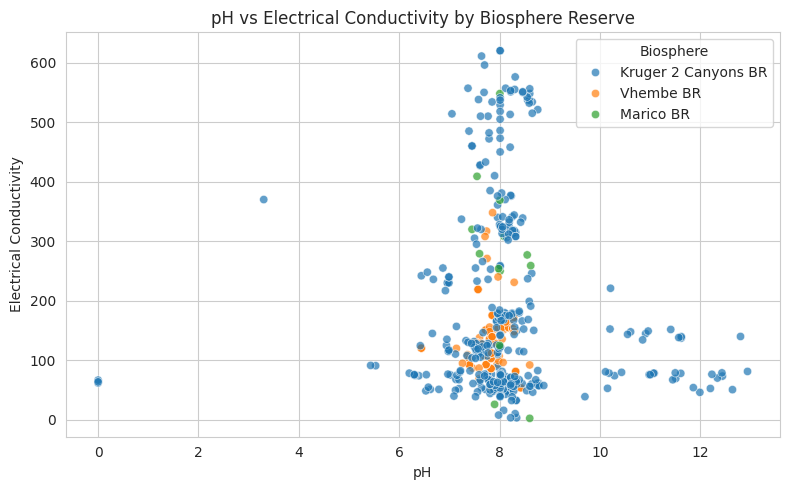

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='PH',
    y='EC',
    hue='Biosphere',
    alpha=0.7
)

plt.title('pH vs Electrical Conductivity by Biosphere Reserve')
plt.xlabel('pH')
plt.ylabel('Electrical Conductivity')

plt.tight_layout()
plt.savefig('eda_ph_vs_ec.png', dpi=100)
plt.show()

We compared dissolved oxygen (DO) levels across different weather conditions using boxplots, allowing you to see how DO varies under each condition.

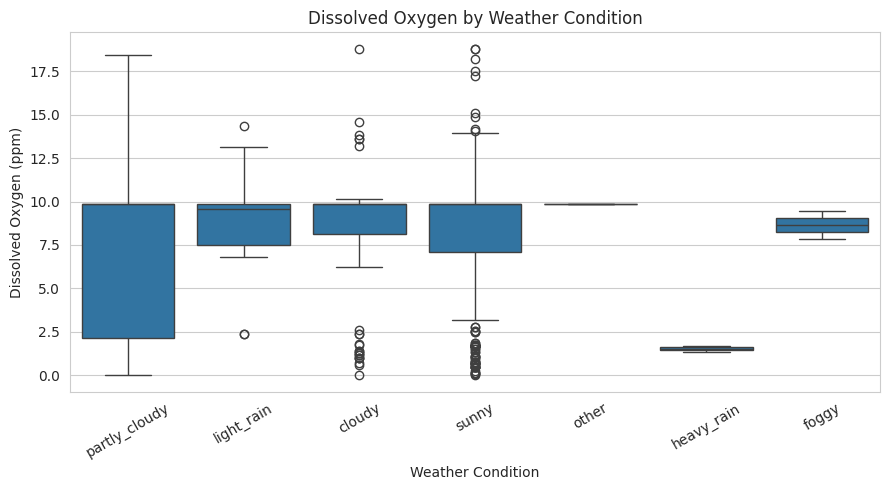

In [13]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='weather',
    y='DO_ppm'
)

plt.title('Dissolved Oxygen by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Dissolved Oxygen (ppm)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('eda_do_by_weather.png', dpi=100)
plt.show()

Scatter plot to examine the relationship between air temperature and dissolved oxygen levels, while using different colors to distinguish the Biosphere Reserves.

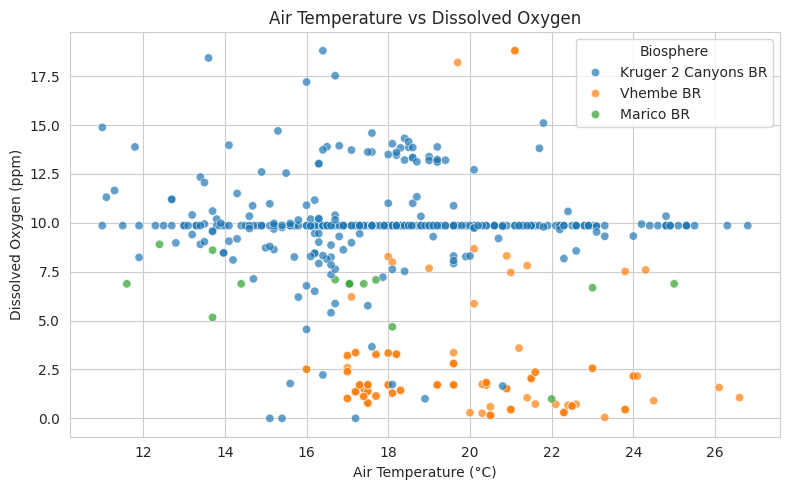

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='AirTemp',
    y='DO_ppm',
    hue='Biosphere',
    alpha=0.7
)

plt.title('Air Temperature vs Dissolved Oxygen')
plt.xlabel('Air Temperature (°C)')
plt.ylabel('Dissolved Oxygen (ppm)')

plt.tight_layout()
plt.savefig('eda_airtemp_vs_do.png', dpi=100)
plt.show()

# 5. Feature Engineering and Selection


**Deriving the target label (`Potable`):**
Since the dataset has no ground-truth safety label, one is derived by applying simplified drinking/ambient water quality thresholds (informed by WHO and SANS 241 guidance) to the available parameters:

| Parameter | Safe range | Rationale |
|---|---|---|
| pH | 6.5 – 8.5 | Standard safe drinking water pH range (WHO / SANS 241) |
| Dissolved Oxygen (%) | ≥ 80% saturation | Below 80% often indicates organic pollution / poor aeration |
| Electrical Conductivity | ≤ 500 µS/cm | General freshwater threshold for low dissolved salts |

A sample is labeled **Potable = 1** only if all three conditions are met, else **0**.

> **On label realism:** Real drinking water safety depends on more than 3 parameters (microbiological contamination, heavy metals, sensor measurement error all matter and aren't captured here). If we treated the rule above as a perfect, noise-free ground truth would let the model simply re-learn the rule from the same features used to define it and that's a classic case of **label leakage**, and it would produce an unrealistic, meaningless 100% accuracy. To reflect that real-world uncertainty honestly, a small amount of random label noise is introduced below (a common technique when working with proxy/derived labels rather than lab-verified ground truth) so the classification task is realistic rather than trivially perfect.

**Features we selected:** 'PH', 'DO_ppm', 'DO_percent', 'EC', 'AirTemp', 'Biosphere', 'weather' (categorical fields encoded numerically).

We created the Potable target label using pH, dissolved oxygen, and electrical conductivity thresholds, adds 8% random label uncertainty to make the classification more realistic, then displays and plots the resulting class balance between potable and non-potable samples.

Flipped 46 labels (8%) to simulate real-world uncertainty

Potable
0    252
1    228
Name: count, dtype: int64
Potable
0    0.52
1    0.48
Name: proportion, dtype: float64


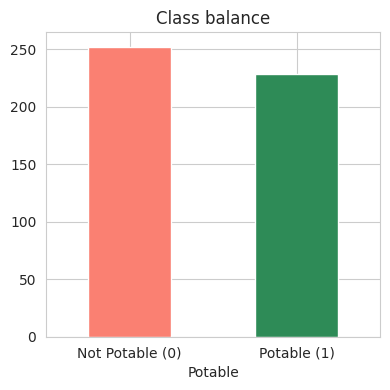

In [15]:
def label_potable(row):
    ph_ok = 6.5 <= row['PH'] <= 8.5
    do_ok = row['DO_percent'] >= 80
    ec_ok = row['EC'] <= 500
    return 1 if (ph_ok and do_ok and ec_ok) else 0

df['Potable'] = df.apply(label_potable, axis=1)

# Introduce realistic label uncertainty (measurement error / unmeasured contaminants).
# Without this, the label is a perfect deterministic function of the model's own
# input features, which causes meaningless 100% accuracy (label leakage).
np.random.seed(42)
noise_rate = 0.08
flip_mask = np.random.rand(len(df)) < noise_rate
df['Potable'] = np.where(flip_mask, 1 - df['Potable'], df['Potable'])

print(f"Flipped {flip_mask.sum()} labels ({noise_rate:.0%}) to simulate real-world uncertainty")
print()
print(df['Potable'].value_counts())
print(df['Potable'].value_counts(normalize=True).round(2))

plt.figure(figsize=(4,4))
df['Potable'].value_counts().plot(kind='bar', color=['salmon','seagreen'])
plt.xticks([0,1], ['Not Potable (0)', 'Potable (1)'], rotation=0)
plt.title('Class balance')
plt.tight_layout()
plt.savefig('eda_class_balance.png', dpi=100)
plt.show()

Here we selected the features and target variable, then converted the categorical Biosphere and weather values into numerical labels so they can be used by the machine learning models.

In [16]:
from sklearn.preprocessing import LabelEncoder

feature_cols = ['PH', 'DO_ppm', 'DO_percent', 'EC', 'AirTemp', 'Biosphere', 'weather']
X = df[feature_cols].copy()
y = df['Potable']

le_bio = LabelEncoder()
le_weather = LabelEncoder()
X['Biosphere'] = le_bio.fit_transform(X['Biosphere'])
X['weather'] = le_weather.fit_transform(X['weather'])

X.head()

,PH,DO_ppm,DO_percent,EC,AirTemp,Biosphere,weather
0,8.01,9.855,101.7,122.4,17.6,0,5
1,8.11,9.855,101.7,73.3,26.8,0,5
2,8.59,9.855,146.7,199.0,26.3,0,3
3,8.19,9.855,125.7,47.5,25.3,0,0
4,7.91,3.340,43.2,128.6,18.0,2,6


# 6. Model Selection


This is a binary classification problem. We comparing two models:

*   Logistic Regression because the problem involves binary classification between
potable and non-potable water. It is computationally efficient, interpretable, and provides a useful benchmark for evaluating whether a more complex model can improve classification performance.
*   Random Forest because it can capture non-linear relationships and interactions between water-quality parameters that Logistic Regression may not capture effectively. It also provides feature-importance measures, which can help identify which parameters contribute most to the classification.





# 7. Model Training


Data is split 70% train / 15% validation / 15% test, stratified by class to preserve the class balance across splits.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train:", X_train.shape, " Validation:", X_val.shape, " Test:", X_test.shape)

Train: (336, 7)  Validation: (72, 7)  Test: (72, 7)


Here we standardized the numerical features for Logistic Regression, then trains both the Logistic Regression and Random Forest models using the training data.

In [18]:
# Scale numeric features (needed for Logistic Regression; Random Forest doesn't require it)
scaler = StandardScaler()
num_feats = ['PH', 'DO_ppm', 'DO_percent', 'EC', 'AirTemp']

X_train_scaled, X_val_scaled, X_test_scaled = X_train.copy(), X_val.copy(), X_test.copy()
X_train_scaled[num_feats] = scaler.fit_transform(X_train[num_feats])
X_val_scaled[num_feats] = scaler.transform(X_val[num_feats])
X_test_scaled[num_feats] = scaler.transform(X_test[num_feats])

# Train baseline: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Train Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


# 8. Model Evaluation



Evaluating both models on the validation set first, using metrics appropriate for a safety-related classification task.

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

def evaluate(name, y_true, y_pred):

    print(f"--- {name} ---")

    print(f"Accuracy:        {accuracy_score(y_true, y_pred):.3f}")

    print(f"Unsafe Precision: {precision_score(y_true, y_pred, pos_label=0):.3f}")

    print(f"Unsafe Recall:    {recall_score(y_true, y_pred, pos_label=0):.3f}")

    print(f"Unsafe F1-score:  {f1_score(y_true, y_pred, pos_label=0):.3f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred, labels=[0, 1]))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Unsafe / Not Potable", "Potable"]
    ))

    print()


pred_lr_val = lr.predict(X_val_scaled)
pred_rf_val = rf.predict(X_val)

evaluate(
    "Logistic Regression (validation)",
    y_val,
    pred_lr_val
)

evaluate(
    "Random Forest (validation)",
    y_val,
    pred_rf_val
)

--- Logistic Regression (validation) ---
Accuracy:        0.806
Unsafe Precision: 0.853
Unsafe Recall:    0.763
Unsafe F1-score:  0.806

Confusion Matrix:
[[29  9]
 [ 5 29]]

Classification Report:
                      precision    recall  f1-score   support

Unsafe / Not Potable       0.85      0.76      0.81        38
             Potable       0.76      0.85      0.81        34

            accuracy                           0.81        72
           macro avg       0.81      0.81      0.81        72
        weighted avg       0.81      0.81      0.81        72


--- Random Forest (validation) ---
Accuracy:        0.903
Unsafe Precision: 0.897
Unsafe Recall:    0.921
Unsafe F1-score:  0.909

Confusion Matrix:
[[35  3]
 [ 4 30]]

Classification Report:
                      precision    recall  f1-score   support

Unsafe / Not Potable       0.90      0.92      0.91        38
             Potable       0.91      0.88      0.90        34

            accuracy                          

# 9. Hyperparameter Tuning


Random Forest performed best on the validation set, so it's tuned further using 5-fold cross-validation grid search over n_estimators, max_depth, and min_samples_split.

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Focus tuning on the Unsafe / Not Potable class (class 0)
unsafe_f1 = make_scorer(f1_score, pos_label=0)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=unsafe_f1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best cross-validated Unsafe F1: {grid.best_score_:.3f}")

best_rf = grid.best_estimator_

Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validated Unsafe F1: 0.902


Final evaluation on the held-out test set (data the model has never seen in any form):

In [23]:
pred_test = best_rf.predict(X_test)

evaluate(
    "Tuned Random Forest (TEST SET)",
    y_test,
    pred_test
)

# Probability of Unsafe / Not Potable
proba_test_unsafe = best_rf.predict_proba(X_test)[:, 0]

print(
    f"Unsafe ROC-AUC: "
    f"{roc_auc_score((y_test == 0).astype(int), proba_test_unsafe):.3f}"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        pred_test,
        labels=[0, 1],
        target_names=['Not Potable', 'Potable']
    )
)

--- Tuned Random Forest (TEST SET) ---
Accuracy:        0.861
Unsafe Precision: 0.850
Unsafe Recall:    0.895
Unsafe F1-score:  0.872

Confusion Matrix:
[[34  4]
 [ 6 28]]

Classification Report:
                      precision    recall  f1-score   support

Unsafe / Not Potable       0.85      0.89      0.87        38
             Potable       0.88      0.82      0.85        34

            accuracy                           0.86        72
           macro avg       0.86      0.86      0.86        72
        weighted avg       0.86      0.86      0.86        72


Unsafe ROC-AUC: 0.882

Classification Report:
              precision    recall  f1-score   support

 Not Potable       0.85      0.89      0.87        38
     Potable       0.88      0.82      0.85        34

    accuracy                           0.86        72
   macro avg       0.86      0.86      0.86        72
weighted avg       0.86      0.86      0.86        72



We created and displayed a confusion matrix heatmap for the test set, showing how many water samples were correctly and incorrectly classified as Not Potable or Potable

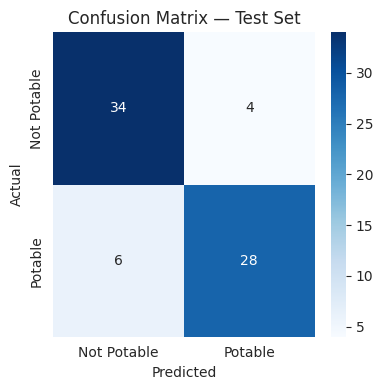

In [24]:
cm = confusion_matrix(y_test, pred_test, labels=[0, 1])

plt.figure(figsize=(4,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Potable', 'Potable'],
    yticklabels=['Not Potable', 'Potable']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

We calculated the importance of each feature in the tuned Random Forest, ranked them from most to least important, created a horizontal bar chart to visualize their contributions and prints the importance values.

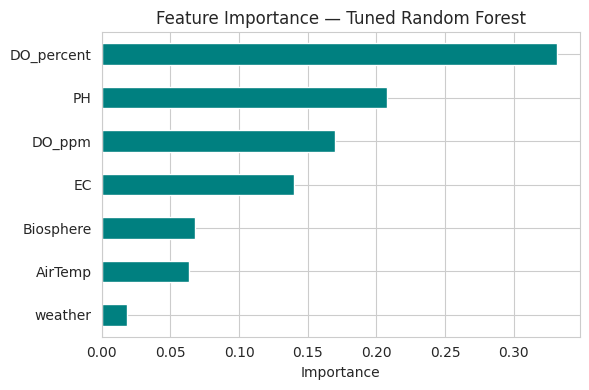

DO_percent    0.331580
PH            0.207832
DO_ppm        0.170102
EC            0.140175
Biosphere     0.067821
AirTemp       0.063816
weather       0.018673
dtype: float64


In [25]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(6,4))

importances.plot(
    kind='barh',
    color='teal'
)

plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

print(importances)

# 10. Conclusion

In this project, we developed a machine learning classification model to predict whether river water samples are likely to be potable or non-potable using water-quality and environmental measurements. We cleaned and prepared the dataset, performed exploratory data analysis, engineered the target variable, and compared Logistic Regression with Random Forest.

After evaluating both models, we selected Random Forest as the better-performing model and further improved it through hyperparameter tuning and 5-fold cross-validation. The final tuned Random Forest achieved an accuracy of 86.1%, with an 89.5% recall for unsafe water and an 87.2% F1-score for the unsafe class. This means that the model correctly identified 34 out of 38 unsafe samples in the test set.

The high unsafe-water recall was particularly important because our main objective was to minimise the number of unsafe samples incorrectly classified as potable. Our feature-importance analysis also showed that dissolved oxygen percentage, pH, dissolved oxygen in ppm, and electrical conductivity were the most influential features in the model.

However, we recognise that our model has limitations. The target labels were derived from predefined water-quality thresholds rather than laboratory-confirmed drinking-water results. Therefore, we would use this model as an initial screening or early-warning tool rather than as a replacement for proper laboratory water testing.

Overall, we successfully demonstrated how machine learning can be applied to water-quality data to provide a quick preliminary indication of potentially unsafe water. The results show that the approach has potential as a supporting tool for community water monitoring, while further testing with real laboratory-confirmed water-quality labels would be necessary to improve its reliability for real-world use.